In [1]:
import json

with open("candidate_pool.json", "r") as f:
    data = json.load(f)

print(json.dumps(data[:3], indent=2))

[
  {
    "candidate_id": "CAND_0000001",
    "career_history": [
      {
        "company": "Mindtree",
        "title": "Backend Engineer",
        "start_date": "2024-03-08",
        "end_date": null,
        "duration_months": 27,
        "is_current": true,
        "industry": "IT Services",
        "company_size": "10001+",
        "description": "Implemented streaming data pipelines on Kafka and Spark Streaming for a real-time user-activity processing platform. Designed the schema-registry integration, the watermark/state management approach, and the deduplication logic for late-arriving events. Worked closely with the data science team to make sure feature pipelines aligned with what their models needed. Most of my career has been data engineering, with some adjacent ML exposure."
      },
      {
        "company": "Dunder Mifflin",
        "title": "Analytics Engineer",
        "start_date": "2019-07-03",
        "end_date": "2024-01-08",
        "duration_months": 55,
      

In [2]:
len(data)

4667

In [3]:


with open("jd_structured.json", "r") as f:
    jd = json.load(f)

print(json.dumps(jd, indent=2))

{
  "role_title": "Senior AI Engineer \u2014 Founding Team",
  "role_category": "Applied ML / Information Retrieval / Search & Recommendation",
  "experience": {
    "min_years": 5,
    "max_years": 9
  },
  "core_problem": [
    "The current candidate matching/search system relies on brittle, low-leverage BM25 and rule-based scoring.",
    "The company needs to quickly design, deploy, and scale a high-leverage v2 hybrid search and ranking engine that directly impacts user engagement.",
    "Lack of evaluation infrastructure (A/B testing, offline benchmarks, feedback loops) makes it impossible to systematically improve search relevance without flying blind."
  ],
  "must_have_skills": [
    "Production experience with embedding-based retrieval models (sentence-transformers, BGE, E5, etc.)",
    "Production management of vector databases or hybrid search index lifecycle (index refresh, handling drift, quality regression)",
    "Strong, production-grade Python coding skills",
    "Rigoro

# YOE

In [15]:
import pandas as pd

df = pd.DataFrame(data)

print(df.shape)
df.head()

(4667, 109)


,candidate_id,career_history,education,skills,certifications,languages,redrob_signals.profile_completeness_score,redrob_signals.signup_date,redrob_signals.last_active_date,redrob_signals.open_to_work_flag,...,bad_job_dates,bad_duration,timeline_honeypot_score,timeline_honeypot,current_role_text,obvious_reject,candidate_text,relevance_score,title_bonus,retrieval_score
0,CAND_0000001,"[{'company': 'Mindtree', 'title': 'Backend Eng...",[{'institution': 'Lovely Professional Universi...,"[{'name': 'Tailwind', 'proficiency': 'intermed...",[],"[{'language': 'English', 'proficiency': 'profe...",86.9,1760572800000,1779235200000,True,...,False,False,0,False,"backend engineer backend engineer | sql, spark...",False,"backend engineer backend engineer | sql, spark...",17,5,22
1,CAND_0000010,"[{'company': 'Ola', 'title': 'Data Engineer', ...","[{'institution': 'Generic State University', '...","[{'name': 'GCP', 'proficiency': 'beginner', 'e...",[],"[{'language': 'English', 'proficiency': 'nativ...",81.6,1767916800000,1777420800000,False,...,False,False,0,False,data engineer data engineer | data pipelines &...,False,data engineer data engineer | data pipelines &...,13,6,19
2,CAND_0000031,"[{'company': 'Swiggy', 'title': 'Recommendatio...","[{'institution': 'SRM University', 'degree': '...","[{'name': 'Go', 'proficiency': 'intermediate',...",[],"[{'language': 'English', 'proficiency': 'nativ...",83.4,1769558400000,1779580800000,True,...,False,False,0,False,recommendation systems engineer recommendation...,False,recommendation systems engineer recommendation...,14,10,24
3,CAND_0000082,"[{'company': 'Wipro', 'title': 'Data Analyst',...","[{'institution': 'Generic State University', '...","[{'name': 'GANs', 'proficiency': 'advanced', '...","[{'name': 'AWS Certified Cloud Practitioner', ...","[{'language': 'English', 'proficiency': 'profe...",66.2,1731542400000,1769126400000,True,...,False,False,0,False,data analyst data analyst | 7.4+ yrs in data e...,False,data analyst data analyst | 7.4+ yrs in data e...,16,0,16
4,CAND_0000165,"[{'company': 'Mad Street Den', 'title': 'AI Sp...","[{'institution': 'BITS Pilani', 'degree': 'M.E...","[{'name': 'BentoML', 'proficiency': 'advanced'...","[{'name': 'Deep Learning Specialization', 'iss...","[{'language': 'English', 'proficiency': 'nativ...",63.8,1748563200000,1778457600000,True,...,False,False,0,False,ai specialist ai specialist | building ml-powe...,False,ai specialist ai specialist | building ml-powe...,19,8,27


In [16]:
df["profile.years_of_experience"].describe()

count    4667.000000
mean        5.148597
std         1.806420
min         1.200000
25%         3.700000
50%         5.100000
75%         6.500000
max        16.900000
Name: profile.years_of_experience, dtype: float64

In [17]:
yoe_filtered = df[
    (df["profile.years_of_experience"] >= 4) &
    (df["profile.years_of_experience"] <= 10)
].copy()

print("Original:", len(df))
print("After YOE filter:", len(yoe_filtered))

Original: 4667
After YOE filter: 3286


# JD_FIT SCORE

get down to final 500

In [18]:
# Behavioral skill score

In [19]:
def compute_behavioral_scores(row):

    open_to_work_score = (
        100 if row["redrob_signals.open_to_work_flag"] else 0
    )

    days_since_active = (
        pd.Timestamp.today().normalize()
        - pd.to_datetime(
            row["redrob_signals.last_active_date"]
        )
    ).days

    last_active_score = max(0, 100 - days_since_active)

    recruiter_response_score = (
        row["redrob_signals.recruiter_response_rate"] * 100
    )

    applications_score = min(
        row["redrob_signals.applications_submitted_30d"] * 20,
        100
    )

    interview_completion_score = (
        row["redrob_signals.interview_completion_rate"] * 100
    )

    market_activity_score = round(
        0.25 * open_to_work_score +
        0.25 * last_active_score +
        0.20 * recruiter_response_score +
        0.15 * applications_score +
        0.15 * interview_completion_score,
        1
    )

    if row["redrob_signals.notice_period_days"] <= 30:
        notice_score = 100
    elif row["redrob_signals.notice_period_days"] <= 60:
        notice_score = 70
    elif row["redrob_signals.notice_period_days"] <= 90:
        notice_score = 40
    else:
        notice_score = 20

    relocate_score = (
        100
        if row["redrob_signals.willing_to_relocate"]
        else 0
    )

    availability_score = round(
        0.6 * notice_score +
        0.4 * relocate_score,
        1
    )

    github_score = max(
        0,
        min(
            row["redrob_signals.github_activity_score"] * 10,
            100
        )
    )

    profile_score = row[
        "redrob_signals.profile_completeness_score"
    ]

    endorsement_score = min(
        np.log1p(
            row["redrob_signals.endorsements_received"]
        )
        / np.log1p(100)
        * 100,
        100,
    )

    credibility_score = round(
        0.5 * github_score +
        0.3 * profile_score +
        0.2 * endorsement_score,
        1
    )

    return {
        "market_activity_score": market_activity_score,
        "availability_score": availability_score,
        "credibility_score": credibility_score
    }

In [20]:
#candidate skill score

In [21]:
import numpy as np

proficiency_weights = {
    "beginner": 25,
    "intermediate": 50,
    "advanced": 75,
    "expert": 90
}

def calculate_skill_score(skill):

    prof = proficiency_weights.get(
        str(skill.get("proficiency", "intermediate")).lower(),
        50
    )

    endorsement_score = min(
        np.log1p(skill.get("endorsements", 0))
        / np.log1p(100)
        * 100,
        100
    )

    duration_score = min(
        np.log1p(skill.get("duration_months", 0))
        / np.log1p(60)
        * 100,
        100
    )

    score = (
        0.50 * prof +
        0.20 * endorsement_score +
        0.30 * duration_score
    )

    return round(score, 1)
def build_final_skills(row):

    # -------------------------
    # Profile skills
    # -------------------------

    skills_list = row["skills"]

    profile_scores = {}

    for skill in skills_list:

        profile_score = calculate_skill_score(
            pd.Series(skill)
        )

        profile_scores[
            skill["name"]
        ] = profile_score

    # -------------------------
    # Assessment skills
    # -------------------------

    assessment_scores = {}

    for col in row.index:

        if col.startswith(
            "redrob_signals.skill_assessment_scores."
        ):

            score = row[col]

            if pd.notna(score):

                skill_name = col.replace(
                    "redrob_signals.skill_assessment_scores.",
                    ""
                )

                assessment_scores[
                    skill_name
                ] = score

    # -------------------------
    # Merge
    # -------------------------

    final_skills = {}

    all_skills = (
        set(profile_scores)
        | set(assessment_scores)
    )

    for skill in all_skills:

        profile = profile_scores.get(skill)
        assessment = assessment_scores.get(skill)

        if (
            profile is not None
            and assessment is not None
        ):

            final_score = round(
                0.4 * profile +
                0.6 * assessment,
                1
            )

            confidence = "high"

        elif assessment is not None:

            final_score = assessment
            confidence = "medium"

        else:

            final_score = profile
            confidence = "low"

        final_skills[skill] = {
            "score": final_score,
            "confidence": confidence
        }

    return {
        skill: details
        for skill, details in final_skills.items()
        if not (
            details["confidence"] == "low"
            and details["score"] < 50
        )
    }

In [22]:
candidate_records = []

for _, row in yoe_filtered.iterrows():

    behavioral_scores = compute_behavioral_scores(row)

    final_skills = build_final_skills(row)

    candidate_records.append({
        "candidate_id": row["candidate_id"],
        "behavioral_scores": behavioral_scores,
        "final_skills": final_skills
    })

candidate_features = pd.DataFrame(
    candidate_records
)

In [23]:
candidate_features

,candidate_id,behavioral_scores,final_skills
0,CAND_0000001,"{'market_activity_score': 48.4, 'availability_...","{'Tailwind': {'score': 50.3, 'confidence': 'lo..."
1,CAND_0000010,"{'market_activity_score': 30.9, 'availability_...","{'CNN': {'score': 53.0, 'confidence': 'low'}, ..."
2,CAND_0000031,"{'market_activity_score': 58.2, 'availability_...","{'Embeddings': {'score': 91.9, 'confidence': '..."
3,CAND_0000082,"{'market_activity_score': 69.9, 'availability_...","{'FAISS': {'score': 58.5, 'confidence': 'low'}..."
4,CAND_0000165,"{'market_activity_score': 60.4, 'availability_...","{'Vector Search': {'score': 75.6, 'confidence'..."
...,...,...,...
3281,CAND_0099947,"{'market_activity_score': 41.5, 'availability_...","{'CNN': {'score': 74.8, 'confidence': 'low'}, ..."
3282,CAND_0099965,"{'market_activity_score': 71.5, 'availability_...","{'Semantic Search': {'score': 68.8, 'confidenc..."
3283,CAND_0099977,"{'market_activity_score': 56.8, 'availability_...","{'Qdrant': {'score': 54.6, 'confidence': 'low'..."
3284,CAND_0099983,"{'market_activity_score': 53.9, 'availability_...","{'PEFT': {'score': 53.1, 'confidence': 'low'},..."


In [24]:
CORE_IR_SKILLS = {
    "Information Retrieval": 100,
    "Vector Search": 100,
    "Learning to Rank": 95,
    "Recommendation Systems": 95,
    "Semantic Search": 90,
    "Elasticsearch": 90,
    "OpenSearch": 90,
    "FAISS": 85,
    "Pinecone": 85,
    "Qdrant": 85,
    "Milvus": 85,
    "Weaviate": 85,
    "Embeddings": 80,
    "Sentence Transformers": 80,
    "BM25": 75,
    "Python": 75,
    "NLP": 70
}

def compute_jd_skill_score(final_skills):

    weighted_score = 0
    total_weight = 0

    for skill, weight in CORE_IR_SKILLS.items():

        if skill in final_skills:

            weighted_score += (
                final_skills[skill]["score"] * weight
            )

            total_weight += weight

    if total_weight == 0:
        return 0

    return round(
        weighted_score / total_weight,
        2
    )

In [25]:
candidate_features["jd_skill_score"] = (
    candidate_features["final_skills"]
    .apply(compute_jd_skill_score)
)


In [26]:
def count_ir_matches(final_skills):

    return sum(
        1
        for skill in CORE_IR_SKILLS
        if skill in final_skills
    )

candidate_features["ir_match_count"] = (
    candidate_features["final_skills"]
    .apply(count_ir_matches)
)

In [27]:
candidate_features = candidate_features[
    candidate_features["ir_match_count"] >= 3
]

In [28]:
candidate_features

,candidate_id,behavioral_scores,final_skills,jd_skill_score,ir_match_count
1,CAND_0000010,"{'market_activity_score': 30.9, 'availability_...","{'CNN': {'score': 53.0, 'confidence': 'low'}, ...",64.94,3
2,CAND_0000031,"{'market_activity_score': 58.2, 'availability_...","{'Embeddings': {'score': 91.9, 'confidence': '...",79.57,5
3,CAND_0000082,"{'market_activity_score': 69.9, 'availability_...","{'FAISS': {'score': 58.5, 'confidence': 'low'}...",69.67,3
4,CAND_0000165,"{'market_activity_score': 60.4, 'availability_...","{'Vector Search': {'score': 75.6, 'confidence'...",68.69,5
5,CAND_0000184,"{'market_activity_score': 30.6, 'availability_...","{'CNN': {'score': 57.1, 'confidence': 'low'}, ...",66.84,3
...,...,...,...,...,...
3266,CAND_0099401,"{'market_activity_score': 24.6, 'availability_...","{'Qdrant': {'score': 91.4, 'confidence': 'low'...",85.72,6
3270,CAND_0099531,"{'market_activity_score': 28.8, 'availability_...","{'CNN': {'score': 54.3, 'confidence': 'low'}, ...",65.18,3
3273,CAND_0099581,"{'market_activity_score': 57.5, 'availability_...","{'REST APIs': {'score': 59.0, 'confidence': 'l...",74.18,3
3274,CAND_0099630,"{'market_activity_score': 67.2, 'availability_...","{'PEFT': {'score': 53.7, 'confidence': 'high'}...",61.48,3


add behavioral score to compute final llm score

In [29]:
def aggregate_behavior(x):

    return (
        0.4 * x["credibility_score"]
        + 0.4 * x["market_activity_score"]
        + 0.2 * x["availability_score"]
    )

candidate_features["behavior_score"] = (
    candidate_features["behavioral_scores"]
    .apply(aggregate_behavior)
)

/var/folders/lr/nt_9hmbd1fx5ntqlx0dtryn40000gn/T/ipykernel_33664/4193838598.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  candidate_features["behavior_score"] = (


In [30]:
candidate_features["pre_llm_score"] = (
    0.85 * candidate_features["jd_skill_score"]
    + 0.15 * candidate_features["behavior_score"]
)

/var/folders/lr/nt_9hmbd1fx5ntqlx0dtryn40000gn/T/ipykernel_33664/4262799589.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  candidate_features["pre_llm_score"] = (


In [31]:
candidate_features = candidate_features.sort_values(
    "pre_llm_score",
    ascending=False
)

In [32]:
candidate_features

,candidate_id,behavioral_scores,final_skills,jd_skill_score,ir_match_count,behavior_score,pre_llm_score
2912,CAND_0088025,"{'market_activity_score': 70.8, 'availability_...","{'Learning to Rank': {'score': 92.6, 'confiden...",90.87,6,65.44,87.0555
1912,CAND_0058575,"{'market_activity_score': 64.0, 'availability_...","{'Hugging Face Transformers': {'score': 92.8, ...",89.03,3,73.80,86.7455
2274,CAND_0069905,"{'market_activity_score': 69.5, 'availability_...","{'Learning to Rank': {'score': 87.3, 'confiden...",88.46,5,76.24,86.6270
1369,CAND_0041610,"{'market_activity_score': 62.4, 'availability_...","{'OpenSearch': {'score': 92.4, 'confidence': '...",88.35,6,75.72,86.4555
197,CAND_0005649,"{'market_activity_score': 64.6, 'availability_...","{'Prompt Engineering': {'score': 80.6, 'confid...",88.82,4,72.44,86.3630
...,...,...,...,...,...,...,...
2940,CAND_0088842,"{'market_activity_score': 18.1, 'availability_...","{'Embeddings': {'score': 62.0, 'confidence': '...",55.79,4,28.60,51.7115
1861,CAND_0057098,"{'market_activity_score': 14.7, 'availability_...","{'Qdrant': {'score': 71.0, 'confidence': 'low'...",56.72,6,22.04,51.5180
178,CAND_0005147,"{'market_activity_score': 39.1, 'availability_...","{'Embeddings': {'score': 55.7, 'confidence': '...",55.18,5,28.72,51.2110
145,CAND_0004087,"{'market_activity_score': 38.6, 'availability_...","{'OpenSearch': {'score': 56.9, 'confidence': '...",54.18,3,30.04,50.5590


In [33]:
candidate_features["pre_llm_score"] = (
    0.75 * candidate_features["jd_skill_score"]
    + 0.15 * candidate_features["behavior_score"]
    + 0.10 * candidate_features["ir_match_count"] * 10
)

In [34]:
candidate_features

,candidate_id,behavioral_scores,final_skills,jd_skill_score,ir_match_count,behavior_score,pre_llm_score
2912,CAND_0088025,"{'market_activity_score': 70.8, 'availability_...","{'Learning to Rank': {'score': 92.6, 'confiden...",90.87,6,65.44,83.9685
1912,CAND_0058575,"{'market_activity_score': 64.0, 'availability_...","{'Hugging Face Transformers': {'score': 92.8, ...",89.03,3,73.80,80.8425
2274,CAND_0069905,"{'market_activity_score': 69.5, 'availability_...","{'Learning to Rank': {'score': 87.3, 'confiden...",88.46,5,76.24,82.7810
1369,CAND_0041610,"{'market_activity_score': 62.4, 'availability_...","{'OpenSearch': {'score': 92.4, 'confidence': '...",88.35,6,75.72,83.6205
197,CAND_0005649,"{'market_activity_score': 64.6, 'availability_...","{'Prompt Engineering': {'score': 80.6, 'confid...",88.82,4,72.44,81.4810
...,...,...,...,...,...,...,...
2940,CAND_0088842,"{'market_activity_score': 18.1, 'availability_...","{'Embeddings': {'score': 62.0, 'confidence': '...",55.79,4,28.60,50.1325
1861,CAND_0057098,"{'market_activity_score': 14.7, 'availability_...","{'Qdrant': {'score': 71.0, 'confidence': 'low'...",56.72,6,22.04,51.8460
178,CAND_0005147,"{'market_activity_score': 39.1, 'availability_...","{'Embeddings': {'score': 55.7, 'confidence': '...",55.18,5,28.72,50.6930
145,CAND_0004087,"{'market_activity_score': 38.6, 'availability_...","{'OpenSearch': {'score': 56.9, 'confidence': '...",54.18,3,30.04,48.1410


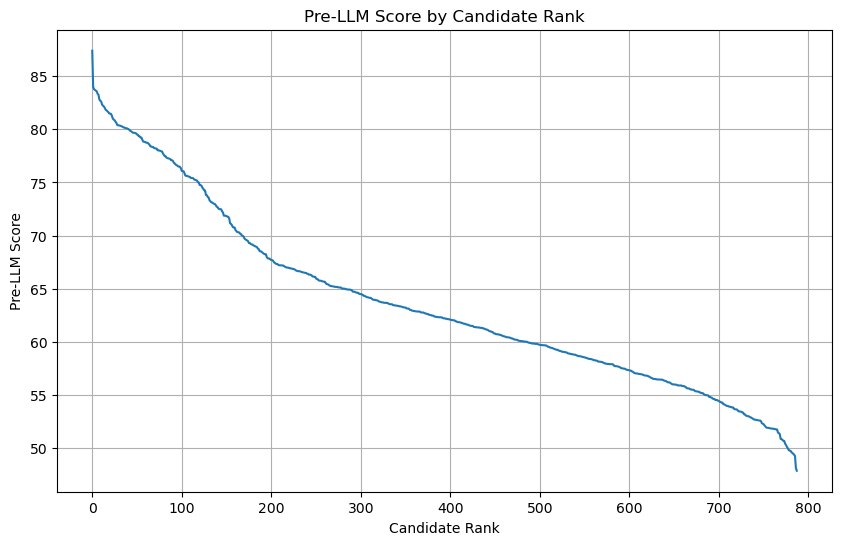

In [35]:
import matplotlib.pyplot as plt
import numpy as np

scores = (
    candidate_features["pre_llm_score"]
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))

plt.plot(
    np.arange(len(scores)),
    scores
)

plt.xlabel("Candidate Rank")
plt.ylabel("Pre-LLM Score")
plt.title("Pre-LLM Score by Candidate Rank")

plt.grid(True)

plt.show()

In [36]:
# Merge profile-related columns into candidate_features
candidate_features = candidate_features.merge(
    df[
        [
            "candidate_id",
            "profile.summary",
            "profile.years_of_experience",
            "profile.current_title",
            "profile.current_company",
            "profile.location",
            "career_history",
            "certifications"
        ]
    ],
    on="candidate_id",
    how="left"
)


# Build a single profile string for each candidate
def build_profile(row):

    # Career history text
    career_text = "\n\n".join(
        f"{job['title']}: {job['description']}"
        for job in row["career_history"]
    ) if isinstance(row["career_history"], list) else ""

    # Certifications text
    cert_text = ", ".join(
        cert["name"]
        for cert in row["certifications"]
    ) if isinstance(row["certifications"], list) else ""

    return f"""
Candidate Summary:
{row['profile.summary']}

Candidate YOE:
{row['profile.years_of_experience']}

Current Role:
{row['profile.current_title']}

Current Company:
{row['profile.current_company']}

Location:
{row['profile.location']}

Career History:
{career_text}

Certifications:
{cert_text}
""".strip()


# Create profile column
candidate_features["profile"] = (
    candidate_features
    .apply(build_profile, axis=1)
)


# Keep only the columns needed for LLM ranking
llm_candidates = candidate_features[
    [
        "candidate_id",
        "profile",
        "jd_skill_score",
        "ir_match_count",
        "behavior_score",
        "pre_llm_score"
    ]
]


# Sort by pre-LLM score
llm_candidates = (
    llm_candidates
    .sort_values(
        "pre_llm_score",
        ascending=False
    )
    .reset_index(drop=True)
)


# Preview
print(llm_candidates.iloc[0]["profile"])

display(llm_candidates.head())

Candidate Summary:
Senior AI engineer with 6.7 years of hands-on experience building production ML systems, with a focus on search, retrieval, and ranking. Most recently, I rebuilt the candidate-JD matching pipeline from scratch, taking it from 0.72 to 0.91 NDCG@10, serving 50M+ queries per month. My day-to-day work spans embedding model selection and fine-tuning, hybrid retrieval architecture, learning-to-rank, behavioral-signal integration, and the offline/online evaluation that ties it all together. I've shipped systems in both early-stage product companies and at larger scale, and I've spent enough time on both that I know which tradeoffs apply where. I have strong opinions about when LLMs are the right hammer and when classical IR is — usually it's both. Currently exploring my next move — looking for senior IC or tech-lead roles where I can own the intelligence layer end-to-end.

Candidate YOE:
6.7

Current Role:
Lead AI Engineer

Current Company:
Razorpay

Location:
Jaipur, Rajas

,candidate_id,profile,jd_skill_score,ir_match_count,behavior_score,pre_llm_score
0,CAND_0081846,Candidate Summary:\nSenior AI engineer with 6....,85.78,10,86.96,87.3790
1,CAND_0088025,Candidate Summary:\nSenior AI engineer with 8....,90.87,6,65.44,83.9685
2,CAND_0018499,Candidate Summary:\nSenior AI engineer with 7....,83.93,8,85.44,83.7635
3,CAND_0007009,Candidate Summary:\nMachine learning engineer ...,87.03,7,76.12,83.6905
4,CAND_0041610,Candidate Summary:\nMachine learning engineer ...,88.35,6,75.72,83.6205


In [37]:
top_candidates = llm_candidates[
    llm_candidates["pre_llm_score"] >= 65
]

In [38]:
top_candidates

,candidate_id,profile,jd_skill_score,ir_match_count,behavior_score,pre_llm_score
0,CAND_0081846,Candidate Summary:\nSenior AI engineer with 6....,85.78,10,86.96,87.3790
1,CAND_0088025,Candidate Summary:\nSenior AI engineer with 8....,90.87,6,65.44,83.9685
2,CAND_0018499,Candidate Summary:\nSenior AI engineer with 7....,83.93,8,85.44,83.7635
3,CAND_0007009,Candidate Summary:\nMachine learning engineer ...,87.03,7,76.12,83.6905
4,CAND_0041610,Candidate Summary:\nMachine learning engineer ...,88.35,6,75.72,83.6205
...,...,...,...,...,...,...
278,CAND_0021014,Candidate Summary:\nData scientist / ML engine...,69.52,3,66.44,65.1060
279,CAND_0066791,Candidate Summary:\nData scientist / ML engine...,70.48,3,61.08,65.0220
280,CAND_0019961,Candidate Summary:\nSoftware / data profession...,74.57,4,33.96,65.0215
281,CAND_0061175,Candidate Summary:\nData scientist / ML engine...,66.66,6,60.12,65.0130


In [39]:
llm_candidates = top_candidates[
    [
        "candidate_id",
        "profile",
        "jd_skill_score",
        "behavior_score"
    ]
].copy()

In [40]:
llm_candidates

,candidate_id,profile,jd_skill_score,behavior_score
0,CAND_0081846,Candidate Summary:\nSenior AI engineer with 6....,85.78,86.96
1,CAND_0088025,Candidate Summary:\nSenior AI engineer with 8....,90.87,65.44
2,CAND_0018499,Candidate Summary:\nSenior AI engineer with 7....,83.93,85.44
3,CAND_0007009,Candidate Summary:\nMachine learning engineer ...,87.03,76.12
4,CAND_0041610,Candidate Summary:\nMachine learning engineer ...,88.35,75.72
...,...,...,...,...
278,CAND_0021014,Candidate Summary:\nData scientist / ML engine...,69.52,66.44
279,CAND_0066791,Candidate Summary:\nData scientist / ML engine...,70.48,61.08
280,CAND_0019961,Candidate Summary:\nSoftware / data profession...,74.57,33.96
281,CAND_0061175,Candidate Summary:\nData scientist / ML engine...,66.66,60.12


In [ ]:
import pandas as pd
llm_candidates.to_pickle("llm_candidates.pkl")

In [15]:
import pandas as pd

llm_candidates = pd.read_pickle("llm_candidates.pkl")

In [16]:
llm_candidates

,candidate_id,profile,jd_skill_score,behavior_score
0,CAND_0081846,Candidate Summary:\nSenior AI engineer with 6....,85.78,86.96
1,CAND_0088025,Candidate Summary:\nSenior AI engineer with 8....,90.87,65.44
2,CAND_0018499,Candidate Summary:\nSenior AI engineer with 7....,83.93,85.44
3,CAND_0007009,Candidate Summary:\nMachine learning engineer ...,87.03,76.12
4,CAND_0041610,Candidate Summary:\nMachine learning engineer ...,88.35,75.72
...,...,...,...,...
278,CAND_0021014,Candidate Summary:\nData scientist / ML engine...,69.52,66.44
279,CAND_0066791,Candidate Summary:\nData scientist / ML engine...,70.48,61.08
280,CAND_0019961,Candidate Summary:\nSoftware / data profession...,74.57,33.96
281,CAND_0061175,Candidate Summary:\nData scientist / ML engine...,66.66,60.12


# TOP 150

In [19]:
llm_candidates=llm_candidates[:150]

import json
with open("jd_structured.json", "r") as f:
    jd = json.load(f)

LLM reasoning Testing 

In [ ]:
import json
import pandas as pd
import google.generativeai as genai

genai.configure(api_key="api_key")

model = genai.GenerativeModel("gemini-2.5-flash")

results = []

for _, row in llm_candidates.iterrows():

    candidate_id = row["candidate_id"]
    profile = row["profile"]
    jd_skill_score = row["jd_skill_score"]
    behavior_score = row["behavior_score"]

    prompt = f"""
You are an elite technical recruiter hiring for the following role.

JOB DESCRIPTION:
{json.dumps(jd, indent=2)}

CANDIDATE:
{profile}

ADDITIONAL SIGNALS:
jd_skill_score = {jd_skill_score}
behavior_score = {behavior_score}

Evaluate the candidate.

Prioritize:

1. Production Ranking & Retrieval Experience (35%)
2. Production Python Coding & Architecture (25%)
3. Evaluation Rigor (NDCG, MRR, MAP, A/B testing) (20%)
4. Product Startup Shipper Mindset (20%)

Penalize:
- Pure research profiles.
- Pure CV/audio/robotics specialists.
- Consulting-only backgrounds.
- Wrapper-API engineers.
- Lack of production evidence.
- Excessive job hopping.
- Impossible timelines or suspicious claims.

Return ONLY valid JSON in this exact format:

{{
"candidate_id":"{candidate_id}",
"production_retrieval_score":0,
"python_architecture_score":0,
"evaluation_rigor_score":0,
"shipper_score":0,
"overall_score":0,
"confidence":"high",
"verdict":"strong hire",
"strengths":[""],
"weaknesses":[""],
"reasoning":""
}}
Scoring Guidelines:

95-100 : Exceptional / unicorn candidate
90-94 : Outstanding hire
80-89 : Strong hire
70-79 : Hire
60-69 : Borderline
Below 60 : Reject

Do not inflate scores. Most candidates should fall between 65 and 85. Assign 95+ only when there is explicit evidence of owning production search/ranking systems and evaluation infrastructure.
overall_score must be the weighted average.
No markdown.
No explanations outside JSON.
"""

    try:

        response = model.generate_content(prompt)

        text = (
            response.text
            .replace("```json", "")
            .replace("```", "")
            .strip()
        )

        result = json.loads(text)

    except Exception as e:

        result = {
            "candidate_id": candidate_id,
            "production_retrieval_score": 0,
            "python_architecture_score": 0,
            "evaluation_rigor_score": 0,
            "shipper_score": 0,
            "overall_score": 0,
            "confidence": "low",
            "verdict": "error",
            "strengths": [],
            "weaknesses": [],
            "reasoning": str(e)
        }

    results.append(result)

final_ranking = (
    pd.DataFrame(results)
    .sort_values(
        "overall_score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(final_ranking.head(100))

In [97]:
final_ranking["reasoning"][0]

"The candidate is an outstanding fit for the Senior AI Engineer — Founding Team role. With 7.2 years of experience at a product company (Zomato), they perfectly embody the 'Product-Minded ML Shipper' archetype. They have directly addressed the core problems of the role by designing and deploying hybrid retrieval systems combining BM25, dense embeddings (BGE, FAISS), LLM re-rankers, and Learning-to-Rank models serving high query volumes. Their expertise in building offline evaluation frameworks (NDCG, MRR, A/B testing calibration) from scratch directly solves a key challenge. The candidate demonstrates strong production-grade Python coding and architectural skills through practical examples of LLM fine-tuning (LoRA, QLoRA), deployment optimization (quantization, BentoML, Kubernetes), and cost reduction. Critically, their experience with 'recruiter-facing search product' and 'candidate-JD matching' is a direct hit on a hidden requirement for an intuitive grasp of HR-tech. The candidate's

In [98]:
final_ranking["reasoning"][1]

"This candidate is an outstanding fit for the Senior AI Engineer — Founding Team role. They directly address virtually every 'must-have' skill and core problem outlined in the job description. Their experience at Yellow.ai demonstrates deep ownership of production-scale hybrid retrieval and ranking systems, from embedding model selection and fine-tuning to vector database management, Learning-to-Rank, and behavioral signal integration. Crucially, they explicitly highlight their expertise in evaluation, including building offline metrics that correlate with online engagement and extensive A/B testing, which is a major pain point for the hiring company. The candidate's focus on business impact (improving recruiter engagement by 24%, reducing time-to-shortlist by 38%) and their willingness to handle 'boring infrastructure' strongly align with the desired 'Product Startup Shipper Mindset'. Their background with a 'candidate corpus' indicates an intuitive grasp of recruitment domain challen